<a href="https://colab.research.google.com/github/adtapiagonzalez/PracticasRedesNeuronales_Adrian_Tapia/blob/main/PRACTICA_04_Adrian_Tapia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>04. Clasificación con MLP</b></font>
# Adrián Manuel Tapia González

# Ejercicio 1

Usando el generador de pelotas make_blobs crea unos datos con 4 categorías y calcula un MLP para hacer la clasificación.

Ahora tendrás que modificar como ploteas

Y también la última función de activación de la red será una SoftMax

Al igual que con BCE, se prefiere la opción de hacer implicita esas funciones de activación y que sea la función que calcula la función de coste la que las incluya, es decir:


```python
# no se pone la softmax porque va incluida en el optimizador
# torch.nn.Softmax(dim=4)

...

# ya incluye automaticamente las softmax al definir fn_loss
loss_fn = torch.nn.CrossEntropyLoss()
```

Pasa lo mismo, no se pone la capa de softmax, va implicita al definir la funcion criterion = nn.CrossEntropyLoss() # Combina softmax y NLLLoss

ahora la matriz de confusion es MulticlassConfusionMatrix(4)

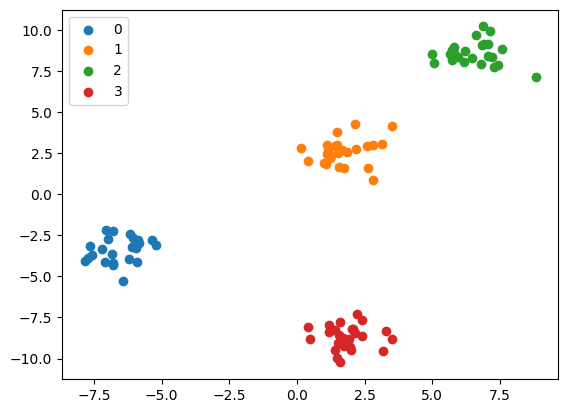

In [110]:
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

X, y = make_blobs(centers=4, cluster_std=0.8) # Se crean 4 centros con una dispersión de 0.8

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="2")
plt.scatter(X[y == 3, 0], X[y == 3, 1], label="3")
# Se etiquetan

plt.legend()
plt.show()

In [111]:
!pip install torcheval

In [112]:
# Se normalizan los datos y se crean el dataset y el dataloader
import torch
from torch.utils.data import TensorDataset, DataLoader


x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.LongTensor(y) # Se asegura que sea LongTensor para las etiquetas de clase,
                              # pues se requiere en la clasificación multiclase, en concreto,
                              # es lo que espera recibir torch.nn.CrossEntropyLoss()

my_dataset = TensorDataset(tensor_X,tensor_y)
my_dataloader = DataLoader(my_dataset)

In [136]:
# Es una red con 3 capas (25,25,4), todo relu menos la ultima capa que hace
# la clasificación múltiple con una softmax

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 25),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(25, 25),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(25, 4), # Cambiado a 4, pues son 4 categorías
                                    # Una salida por cada categoría
            # torch.nn.Softmax(dim=4) # No se necesita explicitar,
                                      # pues la función de loss la incluirá implicitamente

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output # Ya no se necesita flatten, pues torch.nn.CrossEntropyLoss()
                      # espera recibir una salida de un vector de logits, al haber 4 categorías

In [137]:
from torcheval.metrics import MulticlassAccuracy, MulticlassConfusionMatrix
# Se importan las funciones necesarias para la clasificación múltiple

# definimos hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2)

loss_fn = torch.nn.CrossEntropyLoss() # No necesita softmax, viene implícito

optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Se usa Adam y un learning rate de 0.01

acc = MulticlassAccuracy() # Se calcula la precisión (accurary) para clasificación múltiple
m_confusion = MulticlassConfusionMatrix(4) # Se calcula la matriz de confusión para clasificación múltiple


In [138]:
num_epochs = 10

loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # En cada epoca se actualiza:
        acc.update(output, targets)      # accuracy

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )


Epoch: 001/010 | Batch 000/100 | Train Loss: 1.52 | Accuracy: 0.00
Epoch: 002/010 | Batch 000/100 | Train Loss: 0.05 | Accuracy: 0.79
Epoch: 003/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.90
Epoch: 004/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.93
Epoch: 005/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.95
Epoch: 006/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.96
Epoch: 007/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.97
Epoch: 008/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.97
Epoch: 009/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.97
Epoch: 010/010 | Batch 000/100 | Train Loss: 0.00 | Accuracy: 0.98


In [139]:
# Vemos que predicciones hace nuestro modelo para nuestro X

model.eval()
yp = model(tensor_X)
yp

tensor([[-1.2556e+01, -3.2626e+00,  6.2271e+00, -1.2450e+01],
        [-5.5743e+00,  3.8242e+00, -6.2345e+00, -6.3675e+00],
        [-1.0471e+01, -2.0490e+00,  4.3441e+00, -1.2018e+01],
        [-4.2171e+00, -1.7592e-01, -1.9121e+01,  1.1624e+01],
        [-4.7823e+00,  8.8368e-01, -1.7109e+01,  1.0716e+01],
        [ 1.0052e+01, -2.2437e+00, -1.8477e+01, -1.2268e+01],
        [ 8.3724e+00, -1.7795e+00, -1.8065e+01, -9.7578e+00],
        [ 9.0004e+00, -1.7217e+00, -1.7261e+01, -1.1540e+01],
        [ 8.0761e+00, -1.2831e+00, -1.6858e+01, -1.0446e+01],
        [-4.3539e+00, -2.1738e-01, -1.9790e+01,  1.2070e+01],
        [ 7.1463e+00, -1.0523e+00, -1.6790e+01, -9.0443e+00],
        [-1.2623e+01, -4.1145e+00,  7.4960e+00, -1.3582e+01],
        [-4.4942e+00, -1.8919e-01, -2.0215e+01,  1.2380e+01],
        [ 7.9255e+00, -1.7194e+00, -1.8094e+01, -8.9599e+00],
        [-1.1490e+01, -3.1067e+00,  6.0843e+00, -1.2811e+01],
        [ 8.0142e+00, -1.3006e+00, -1.7029e+01, -1.0206e+01],
        

In [140]:
# Calculamos una matriz de confusion

k = MulticlassConfusionMatrix(4)
k.update(yp, tensor_y.long())
print(k.compute())

tensor([[25.,  0.,  0.,  0.],
        [ 0., 25.,  0.,  0.],
        [ 0.,  0., 25.,  0.],
        [ 0.,  0.,  0., 25.]])


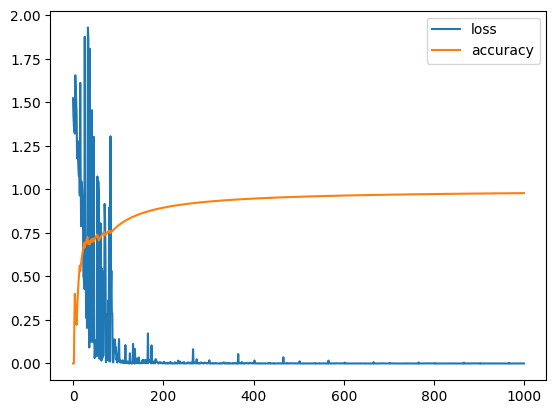

In [141]:
# Ploteamos

plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

La arquitectura de la red es sencilla, con apenas capas ocultas y bajo número de neuronas. Se necesitan pocas épocas para que la red entrene y logre una precisión más que adecuada.

# Ejercicio 2

Haz lo mismo usando make_circles

```python
from sklearn.datasets import make_circles
```


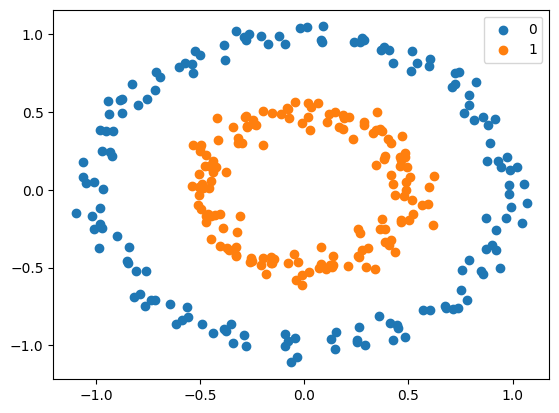

In [142]:
from sklearn.datasets import make_circles
from matplotlib import pyplot as plt
import numpy as np

# Se genera un conjunto de círculos para obtener 2 categorías
X1, y1 = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Se combinan los datos y se ajustan las etiquetas
X = np.vstack((X1))
y = np.hstack((y1))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()
plt.show()

In [143]:
# Se normalizan los datos
import torch
from torch.utils.data import TensorDataset, DataLoader

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y)
my_dataloader = DataLoader(my_dataset, batch_size = 8, shuffle = True)
# En este caso, se hace a través de mini batches

In [144]:
!pip install torcheval
# Es una red con 3 capas (50,25,1), todo relu menos la ultima capa que hace
# la clasificación binaria con una sigmoide, que viene implícita en la función de loss

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 50),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(50, 25),
            torch.nn.ReLU(),


            # output layer
            torch.nn.Linear(25, 1),
            # torch.nn.Sigmoid() # No se necesita explicitar,
                                      # pues la función de loss la incluirá implicitamente

        )

    def forward(self, x):
        output = self.all_layers(x)
        # return output
        return output.flatten()

from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# Se definen los hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2)

loss_fn = torch.nn.BCEWithLogitsLoss() # No necesita sigmoide

optimizer = torch.optim.Adam(model.parameters(), lr=0.003) # Se aumenta el learning rate

acc = BinaryAccuracy() # Se calcula la precisión en clasificación binaria
m_confusion = BinaryConfusionMatrix(threshold=0.5)


num_epochs = 15 # Aumentado el número de épocas a 15, para una mayor oportunidad de aprendizaje

loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets) # targets now matches shape of output

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )


Epoch: 001/015 | Batch 000/038 | Train Loss: 0.81 | Accuracy: 0.88
Epoch: 002/015 | Batch 000/038 | Train Loss: 0.61 | Accuracy: 0.50
Epoch: 003/015 | Batch 000/038 | Train Loss: 0.33 | Accuracy: 0.60
Epoch: 004/015 | Batch 000/038 | Train Loss: 0.12 | Accuracy: 0.73
Epoch: 005/015 | Batch 000/038 | Train Loss: 0.05 | Accuracy: 0.80
Epoch: 006/015 | Batch 000/038 | Train Loss: 0.02 | Accuracy: 0.84
Epoch: 007/015 | Batch 000/038 | Train Loss: 0.04 | Accuracy: 0.86
Epoch: 008/015 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.88
Epoch: 009/015 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.90
Epoch: 010/015 | Batch 000/038 | Train Loss: 0.00 | Accuracy: 0.91
Epoch: 011/015 | Batch 000/038 | Train Loss: 0.00 | Accuracy: 0.92
Epoch: 012/015 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.93
Epoch: 013/015 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.93
Epoch: 014/015 | Batch 000/038 | Train Loss: 0.00 | Accuracy: 0.94
Epoch: 015/015 | Batch 000/038 | Train Loss: 0.00 | Accuracy: 

tensor([[150.,   0.],
        [  0., 150.]])


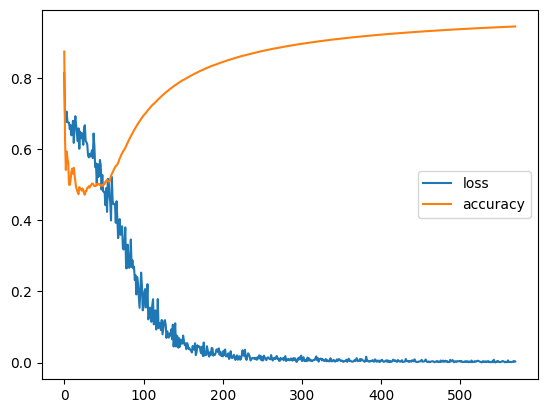

In [145]:
# Predicciones
model.eval()
yp = model(tensor_X)
yp


# Calculamos una matriz de confusion
k = BinaryConfusionMatrix(threshold=0.0)
k.update(yp, tensor_y.long())
print(k.compute())


# Ploteamos
plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

Se puede observar que la clasificación llega a una precisión del 0.94 con un loss cercano a 0. En este caso, para llegar al menos al 0.95 de precisión ha sido necesario aumentar el número épocas (en consecuencia, la oportunidad de entrenamiento) y aumentar el número de neuronas en la primera capa oculta.

# Ejercicio 3

Haz lo mismo usando make_moons

```python
from sklearn.datasets import make_moons
```

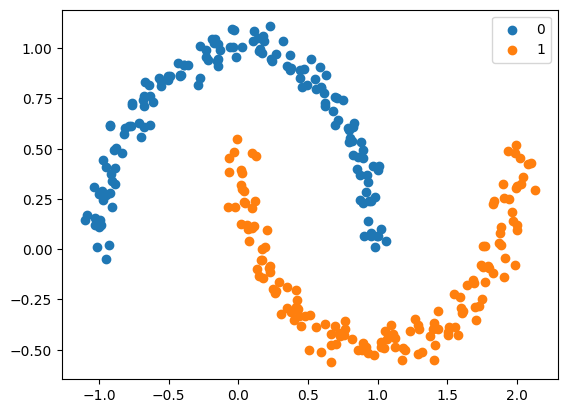

In [147]:
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt
import numpy as np

# Se genera un conjunto de lunas para obtener 2 categorías
X1, y1 = make_moons(n_samples=300, noise=0.05, random_state=42)

X = np.vstack((X1))
y = np.hstack((y1))

# Se combinan los datos
X = np.vstack((X1))
y = np.hstack((y1))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label="0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="1")
plt.legend()
plt.show()

In [148]:
# Se normalizan los datos
import torch
from torch.utils.data import TensorDataset, DataLoader

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm)
tensor_y = torch.Tensor(y)

my_dataset = TensorDataset(tensor_X,tensor_y)
my_dataloader = DataLoader(my_dataset, batch_size = 8, shuffle = True)
# Se añade también mini batch

In [153]:
!pip install torcheval
# Es una red con 3 capas (1000,50,1), todo relu menos la ultima capa que hace
# la clasificación binaria con una sigmoide

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 100),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(100, 50),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(50, 1)
        )

    def forward(self, x):
        output = self.all_layers(x)
        # return output
        return output.flatten()

from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# Se definen los hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=2)

loss_fn = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Se baja el learning rate

acc = BinaryAccuracy()
m_confusion = BinaryConfusionMatrix(threshold = 0.5)


num_epochs = 25 # Aumentado el número de épocas a 25

loss_list, acc_list = [], []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

Epoch: 001/025 | Batch 000/038 | Train Loss: 0.67 | Accuracy: 0.62
Epoch: 002/025 | Batch 000/038 | Train Loss: 0.35 | Accuracy: 0.77
Epoch: 003/025 | Batch 000/038 | Train Loss: 0.13 | Accuracy: 0.82
Epoch: 004/025 | Batch 000/038 | Train Loss: 0.06 | Accuracy: 0.85
Epoch: 005/025 | Batch 000/038 | Train Loss: 0.08 | Accuracy: 0.87
Epoch: 006/025 | Batch 000/038 | Train Loss: 0.17 | Accuracy: 0.89
Epoch: 007/025 | Batch 000/038 | Train Loss: 0.05 | Accuracy: 0.90
Epoch: 008/025 | Batch 000/038 | Train Loss: 0.09 | Accuracy: 0.91
Epoch: 009/025 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.92
Epoch: 010/025 | Batch 000/038 | Train Loss: 0.05 | Accuracy: 0.93
Epoch: 011/025 | Batch 000/038 | Train Loss: 0.00 | Accuracy: 0.94
Epoch: 012/025 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.94
Epoch: 013/025 | Batch 000/038 | Train Loss: 0.02 | Accuracy: 0.95
Epoch: 014/025 | Batch 000/038 | Train Loss: 0.01 | Accuracy: 0.95
Epoch: 015/025 | Batch 000/038 | Train Loss: 0.00 | Accuracy: 

tensor([[150.,   0.],
        [  0., 150.]])


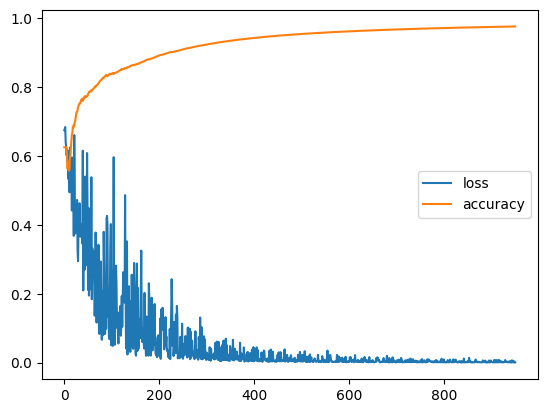

In [154]:
# Predicciones
model.eval()
yp = model(tensor_X)
yp


# Calculamos una matriz de confusion
k = BinaryConfusionMatrix(threshold = 0.5)
k.update(yp, tensor_y.long())
print(k.compute())


# Ploteamos
plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss', 'accuracy'])
plt.show()

En este caso, ha sido necesario aumentar el número de épocas, aumentar el número de neuronas en la segunda capa, y bajar el learning rate. De esta forma, se consigue una adecuada clasificación (0.95) con un loss bajo (cercano a 0). A pesar de haber algo de exploding al principio del entrenamiento, el modelo termina convergiendo finalmente a esta tendencia a un loss de 0.

# Ejercicio 4

Se analizan unos datos obtenido de Kaggle.com sobre una encuesta de infidelidad: [enlace](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Futkarshx27%2Ffairs-extramarital-affairs-data)

Las variables son:

**Criterio**: affairs.

**Predictoras**: gender, age, yearsmarried, children, religiousness, education, occupation, rating.

La variable criterio es de tipo dicotómico **0 = no, 1 = sí** por lo que el análisis convencional nos lleva a un modelo binomial. La precisión (accuracy) en la clasificación obtenida con este modelo es de 0.72

Construye un MLP que supere la precisión del modelo lineal

In [155]:
%reset -f

In [156]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mcstllns/UNIR2024/main/data-affairs.csv'
data  = pd.read_csv(url)
print(data.keys())
data.head()


Index(['affairs', 'gender', 'age', 'yearsmarried', 'children', 'religiousness',
       'education', 'occupation', 'rating'],
      dtype='object')


,affairs,gender,age,yearsmarried,children,religiousness,education,occupation,rating
0,0,0,37.0,10.00,0,3,18,7,4
1,0,1,27.0,4.00,0,4,14,6,4
2,0,1,32.0,15.00,1,1,12,1,4
3,0,0,57.0,15.00,1,5,18,6,5
4,0,0,22.0,0.75,0,2,17,6,3


In [157]:
X = data.drop('affairs', axis=1)
y = data['affairs']

print(X.shape)
print(y.shape)

(601, 8)
(601,)


In [158]:
# Se hace un conteo de las instancias por clase
y.value_counts()

,count
affairs,
0,451
1,150


Se observa que el modelo debe predecir adecuadamente 451 casos en donde no ha habido infidelidad, y 150 casos en donde sí ha habido infidelidad.

In [159]:
# Se normalizan los datos
import torch
from torch.utils.data import TensorDataset, DataLoader

x_mean, x_std = X.mean(), X.std()
X_norm = (X - x_mean) / x_std

tensor_X = torch.Tensor(X_norm.values) # Se pone .values para convertirlo a array,
                                      # pues se requiere este tipo de datos para que
                                      # el modelo trabaje con ellos
tensor_y = torch.Tensor(y.values)

my_dataset = TensorDataset(tensor_X,tensor_y)
my_dataloader = DataLoader(my_dataset, batch_size =32, shuffle = True) # Se aumenta el batch_size

In [160]:
# Es una red con 3 capas (100,50,1), todo relu menos la ultima capa que hace
# la clasificación binaria con una sigmoide

class MLP(torch.nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.all_layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_features, 100),
            torch.nn.LeakyReLU(),

            # 2nd hidden layer
            torch.nn.Linear(100, 50),
            torch.nn.LeakyReLU(),

            # output layer
            torch.nn.Linear(50, 1) # No es necesario hacer explícito la sigmoide

        )

    def forward(self, x):
        output = self.all_layers(x)
        return output.flatten() # Se vuelve a poner flatten para que coincida con el
                                # cálculo de accuracy

from torcheval.metrics import BinaryAccuracy, BinaryConfusionMatrix

# Se definen los hiper-parámetros

torch.manual_seed(1)

model = MLP(num_features=8) # Se añaden hasta 8 features, pues es el número de
                            # variables predictoras

loss_fn = torch.nn.BCEWithLogitsLoss() # No necesita sigmoide, viene implícita en la propia función

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Se mantiene Adam y se baja el lr

acc = BinaryAccuracy() # Se calcula la precisión de clasificación binaria
m_confusion = BinaryConfusionMatrix(threshold=0.5) # Se construye la matriz de confusión binaria
                                                   # con un umbral de 0.5 para darle importancia
                                                   # tanto a aciertos como a rechazos correctos

num_epochs = 1000 # Se aumenta el número de épocas a 1000

# Se guarda el lost y el accuracy
loss_list, acc_list = [], []
loss_epoch_list = []

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0.0
    for batch_idx, (features, targets) in enumerate(my_dataloader):

        # forward
        output = model(features)
        loss = loss_fn(output, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc.update(output, targets)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())
        epoch_loss += loss.item()

        if not batch_idx % 100:
            print(
                f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
                f" | Batch {batch_idx:03d}/{len(my_dataloader):03d}"
                f" | Train Loss: {loss:.2f}"
                f" | Accuracy: {acc.compute():.2f}"
            )

    loss_epoch_list.append(epoch_loss / len(my_dataloader))


Epoch: 001/1000 | Batch 000/019 | Train Loss: 0.67 | Accuracy: 0.69
Epoch: 002/1000 | Batch 000/019 | Train Loss: 0.55 | Accuracy: 0.75
Epoch: 003/1000 | Batch 000/019 | Train Loss: 0.47 | Accuracy: 0.75
Epoch: 004/1000 | Batch 000/019 | Train Loss: 0.43 | Accuracy: 0.75
Epoch: 005/1000 | Batch 000/019 | Train Loss: 0.56 | Accuracy: 0.75
Epoch: 006/1000 | Batch 000/019 | Train Loss: 0.61 | Accuracy: 0.75
Epoch: 007/1000 | Batch 000/019 | Train Loss: 0.59 | Accuracy: 0.75
Epoch: 008/1000 | Batch 000/019 | Train Loss: 0.40 | Accuracy: 0.75
Epoch: 009/1000 | Batch 000/019 | Train Loss: 0.62 | Accuracy: 0.75
Epoch: 010/1000 | Batch 000/019 | Train Loss: 0.37 | Accuracy: 0.75
Epoch: 011/1000 | Batch 000/019 | Train Loss: 0.59 | Accuracy: 0.75
Epoch: 012/1000 | Batch 000/019 | Train Loss: 0.54 | Accuracy: 0.75
Epoch: 013/1000 | Batch 000/019 | Train Loss: 0.42 | Accuracy: 0.75
Epoch: 014/1000 | Batch 000/019 | Train Loss: 0.55 | Accuracy: 0.75
Epoch: 015/1000 | Batch 000/019 | Train Loss: 0.

tensor([[446.,   5.],
        [  3., 147.]])


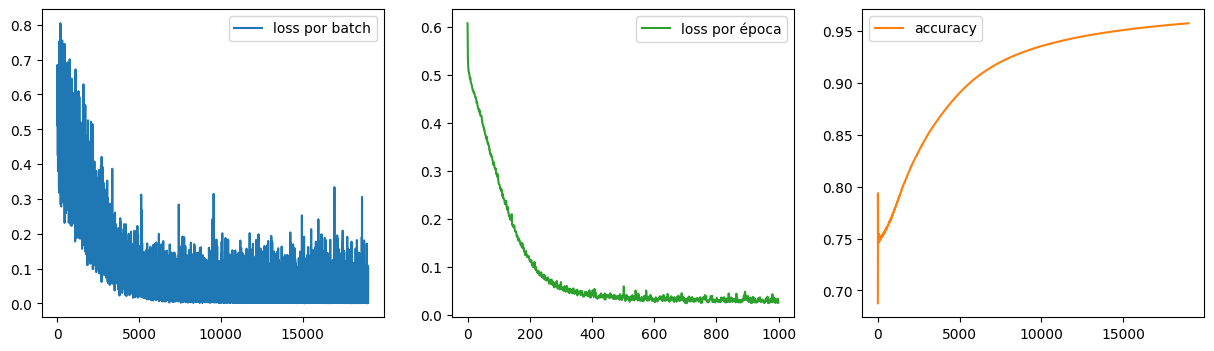

In [161]:
from matplotlib import pyplot as plt
# Predicciones
model.eval()
yp = model(tensor_X)


# Se calcula la matriz de confusion binaria
k = BinaryConfusionMatrix(threshold=0.0)
k.update(yp, tensor_y.long())
print(k.compute())


# Plots de resultados
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(loss_list)
plt.legend(['loss por batch'])

plt.subplot(1, 3, 2)
plt.plot(loss_epoch_list, color='tab:green')
plt.legend(['loss por época'])

plt.subplot(1, 3, 3)
plt.plot(acc_list, color='tab:orange')
plt.legend(['accuracy'])

plt.show()

Este modelo tiene una precisión practicamente perfecta, a excepción de algunos casos, que no logra clasificarlos del todo bien. La elección por este modelo u otro plausible dependerá de la matriz de confusión. La matriz resultado del modelo hace probable el falso negativo, aunque más probable el falso positivo. Si se le da más importancia al falso negativo (es decir, predecir que no hay infidelidad cuando sí la hay), este modelo aún no lograría ser del todo adecuado (aunque por poco). Si se le da más importancia al falso positivo (o sea, predecir qeu sí hay infidelidad pero en realidad no la había), tampoco sería del todo adecuado. En su caso, se podría cambiar el valor del límite a uno menor (por ejemplo, 0.3). Aunque se pueda incrementar los falsos positivos, si se considera más grave no detectar infidelidad, sería una buena decisión. Por su parte, el loss tiende a 0, demostrando el escaso error del modelo y llegando a una precisión bastante alta en comparación con el modelo binomial.